--- 1. TẢI VÀ CHUẨN HÓA DỮ LIỆU CIFAR-10 ---

--- 2. XÂY DỰNG CẤU TRÚC MẠNG CNN ---

--- 3. BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4469 - loss: 1.5287 - val_accuracy: 0.5483 - val_loss: 1.2642
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.5863 - loss: 1.1688 - val_accuracy: 0.6076 - val_loss: 1.0970
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6402 - loss: 1.0207 - val_accuracy: 0.6474 - val_loss: 1.0129
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.6776 - loss: 0.9227 - val_accuracy: 0.6731 - val_loss: 0.9328
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.7024 - loss: 0.8473 - val_accuracy: 0.6859 - val_loss: 0.9019
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7261 - loss: 0.7801 - val_accuracy: 0.6909 - val_loss: 0.8850
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.7430 - los

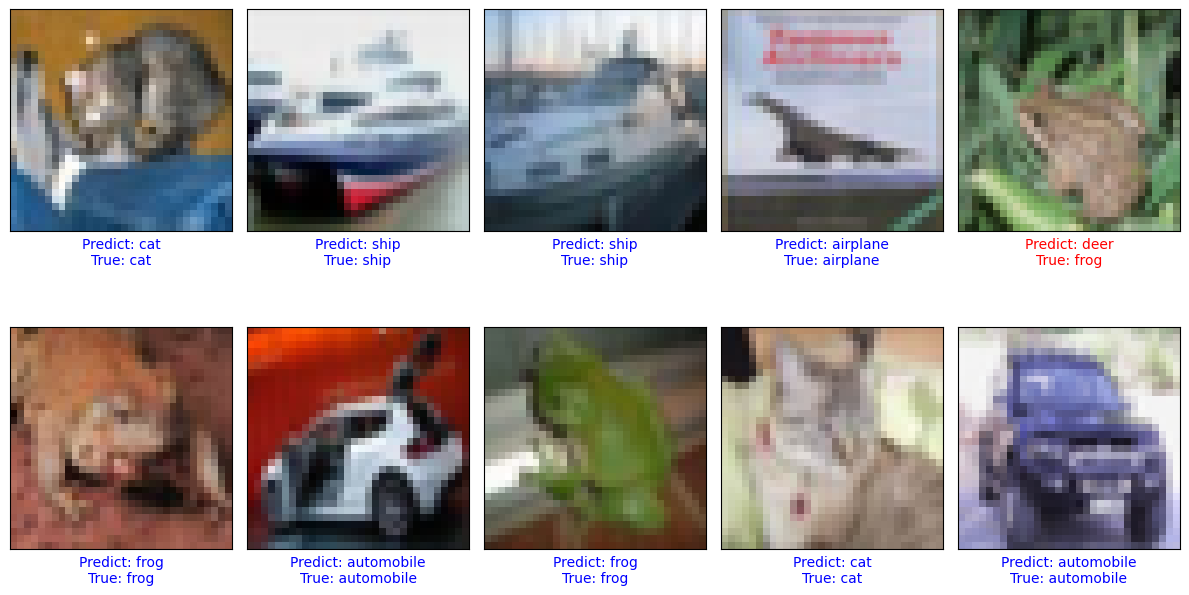

In [ ]:
# -*- coding: utf-8 -*-
"""
Chương trình CNN nhận dạng ảnh trên bộ dataset CIFAR-10 sử dụng TensorFlow/Keras.
Cấu hình hiển thị dự đoán thử nghiệm 10 hình ảnh.
"""

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

def main():
    print("--- 1. TẢI VÀ CHUẨN HÓA DỮ LIỆU CIFAR-10 ---")
    (train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

    # Chuẩn hóa giá trị pixel về khoảng [0, 1]
    train_images, test_images = train_images / 255.0, test_images / 255.0

    # Danh sách 10 nhãn theo đúng thứ tự đề bài yêu cầu
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    print("\n--- 2. XÂY DỰNG CẤU TRÚC MẠNG CNN ---")
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])

    print("\n--- 3. BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH ---")
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

    # Huấn luyện mô hình trong 10 Epochs
    epochs = 10
    history = model.fit(train_images, train_labels, epochs=epochs,
                        validation_data=(test_images, test_labels))

    print("\n--- 4. ĐÁNH GIÁ ĐỘ CHÍNH XÁC ---")
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
    print(f"\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

    print("\n--- 5. DỰ ĐOÁN THỨ NGHIỆM 10 HÌNH ẢNH ĐẦU TIÊN ---")
    # Sử dụng hàm Softmax để chuyển đổi kết quả đầu ra thành xác suất %
    probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
    predictions = probability_model.predict(test_images)

    # Khởi tạo khung chứa ảnh: kích thước 12x7 (rộng x cao) để chứa vừa 2 hàng ảnh
    plt.figure(figsize=(12, 7))

    # Vòng lặp chạy từ 0 đến 9 để vẽ 10 hình ảnh
    for i in range(10):
        # Thiết lập ma trận hiển thị: 2 hàng, 5 cột, vị trí thứ i+1
        plt.subplot(2, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(test_images[i])

        predicted_label = np.argmax(predictions[i])
        true_label = test_labels[i][0]

        # Chữ màu xanh nếu đoán đúng, chữ màu đỏ nếu đoán sai
        color = 'blue' if predicted_label == true_label else 'red'
        plt.xlabel(f"Predict: {class_names[predicted_label]}\nTrue: {class_names[true_label]}", color=color)

    plt.tight_layout() # Tự động căn chỉnh khoảng cách giữa các ảnh không bị đè chữ
    plt.show()

if __name__ == '__main__':
    main()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (10000, 32, 32, 3)
Test shape: (2000, 32, 32, 3)


/tmp/ipykernel_2256/2627151660.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


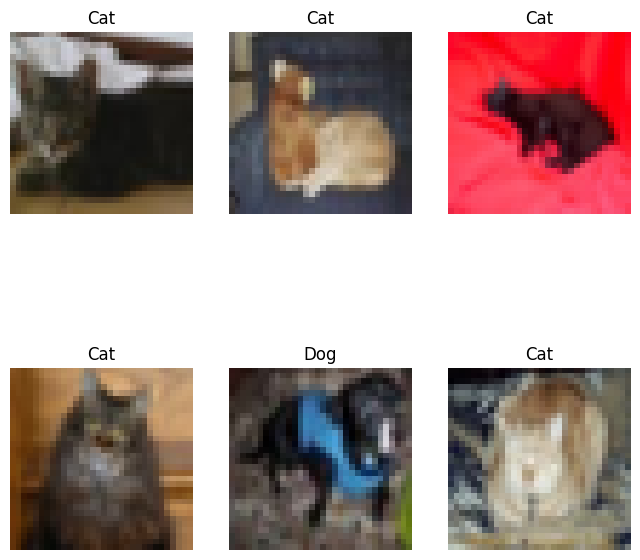

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5810 - loss: 0.6704 - val_accuracy: 0.6500 - val_loss: 0.6351
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6726 - loss: 0.6054 - val_accuracy: 0.6835 - val_loss: 0.5876
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7163 - loss: 0.5505 - val_accuracy: 0.6805 - val_loss: 0.5937
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7462 - loss: 0.5096 - val_accuracy: 0.7400 - val_loss: 0.5221
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7783 - loss: 0.4637 - val_accuracy: 0.7490 - val_loss: 0.5047
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7996 - loss: 0.4248 - val_accuracy: 0.7495 - val_loss: 0.5081
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8247 - loss: 0.3861 - val_accuracy: 0.7535 - val_loss: 0.5270
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8505 - loss: 0.3363 - val_accuracy: 0

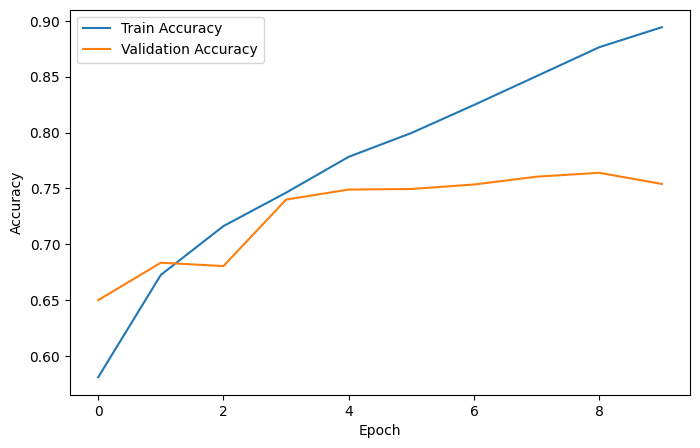

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step

Prediction: Cat
Actual: Cat


/tmp/ipykernel_2256/2627151660.py:139: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Actual:", class_names[int(y_test[0])])


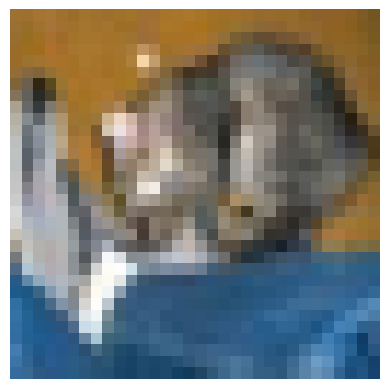


Đã lưu model thành công!


In [9]:
# =========================
# CNN Cat vs Dog - Google Colab
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Load dataset CIFAR-10
# Chỉ lấy Cat và Dog
# =========================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 labels:
# 3 = cat
# 5 = dog

train_filter = np.where((y_train == 3) | (y_train == 5))[0]
test_filter = np.where((y_test == 3) | (y_test == 5))[0]

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Đổi nhãn:
# cat = 0
# dog = 1

y_train = np.where(y_train == 3, 0, 1)
y_test = np.where(y_test == 3, 0, 1)

# Chuẩn hóa ảnh
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# =========================
# Hiển thị ảnh mẫu
# =========================

class_names = ["Cat", "Dog"]

plt.figure(figsize=(8,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.show()

# =========================
# Xây dựng mô hình CNN
# =========================

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

# =========================
# Compile model
# =========================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# Hiển thị model
# =========================

model.summary()

# =========================
# Train model
# =========================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# =========================
# Đánh giá model
# =========================

loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)

# =========================
# Vẽ biểu đồ Accuracy
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# =========================
# Dự đoán thử 1 ảnh
# =========================

prediction = model.predict(x_test[:1])

print("\nPrediction:", "Dog" if prediction[0][0] > 0.5 else "Cat")
print("Actual:", class_names[int(y_test[0])])

plt.imshow(x_test[0])
plt.axis("off")
plt.show()

# =========================
# Lưu model
# =========================

model.save("cat_dog_cnn_model.h5")

print("\nĐã lưu model thành công!")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


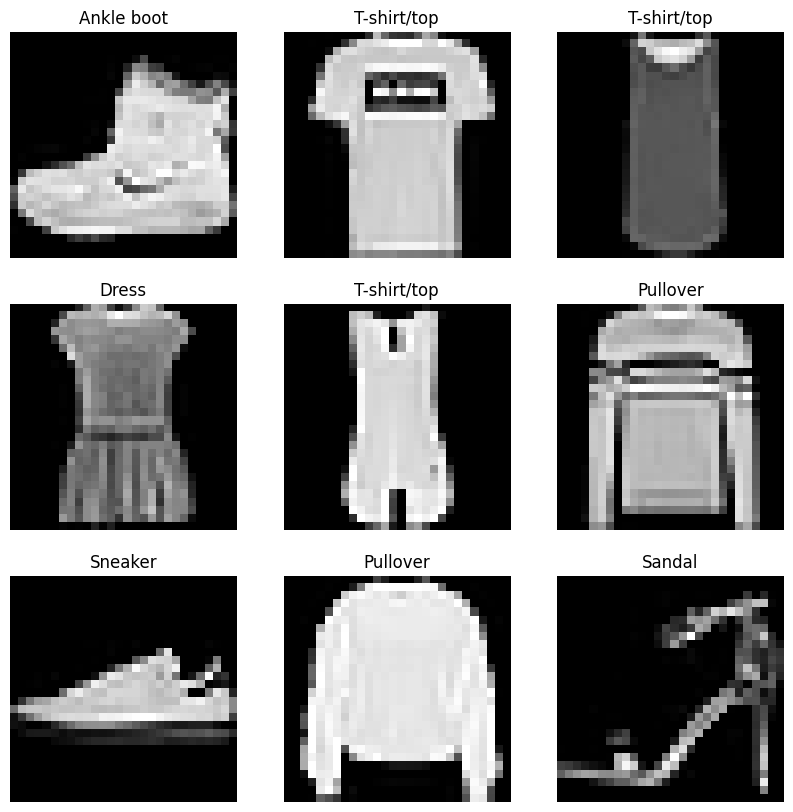

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8422 - loss: 0.4378 - val_accuracy: 0.8716 - val_loss: 0.3553
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8912 - loss: 0.2955 - val_accuracy: 0.8887 - val_loss: 0.2943
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9080 - loss: 0.2486 - val_accuracy: 0.8939 - val_loss: 0.2767
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9190 - loss: 0.2179 - val_accuracy: 0.9059 - val_loss: 0.2571
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9280 - loss: 0.1945 - val_accuracy: 0.9100 - val_loss: 0.2522
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9358 - loss: 0.1702 - val_accuracy: 0.9079 - val_loss: 0.2684
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9437 - loss: 0.1499 - val_accuracy: 0.9151 - val_loss: 0.2614
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9492 - loss: 0.1355 -

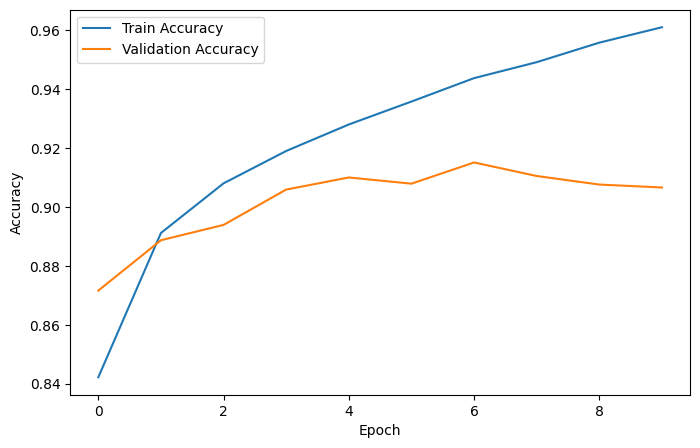

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step

Prediction: Ankle boot
Actual: Ankle boot


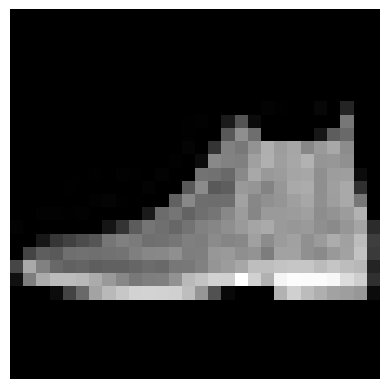


Đã lưu model thành công!


In [10]:
# =========================
# CNN Fashion-MNIST - Google Colab
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Load dataset Fashion-MNIST
# =========================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# =========================
# Chuẩn hóa dữ liệu
# =========================

x_train = x_train / 255.0
x_test = x_test / 255.0

# CNN cần dữ liệu dạng (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# =========================
# Tên các lớp
# =========================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# =========================
# Hiển thị ảnh mẫu
# =========================

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.show()

# =========================
# Xây dựng mô hình CNN
# =========================

model = models.Sequential([

    # CNN Layer 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),
    layers.MaxPooling2D((2,2)),

    # CNN Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

# =========================
# Compile model
# =========================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# Hiển thị model
# =========================

model.summary()

# =========================
# Train model
# =========================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# =========================
# Đánh giá model
# =========================

loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)

# =========================
# Vẽ biểu đồ Accuracy
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# =========================
# Dự đoán thử
# =========================

prediction = model.predict(x_test[:1])

predicted_label = np.argmax(prediction)

print("\nPrediction:", class_names[predicted_label])
print("Actual:", class_names[y_test[0]])

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.axis("off")
plt.show()

# =========================
# Lưu model
# =========================

model.save("fashion_mnist_cnn.h5")

print("\nĐã lưu model thành công!")

Train shape: (10000, 32, 32, 3)
Test shape: (2000, 32, 32, 3)


/tmp/ipykernel_2256/2474219.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


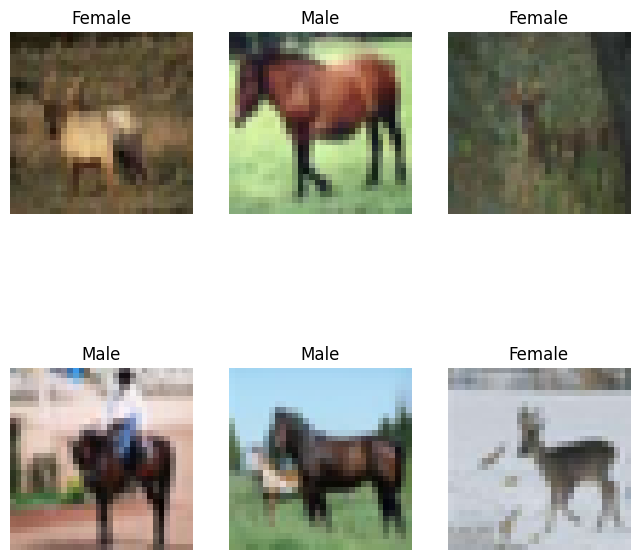

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7400 - loss: 0.5046 - val_accuracy: 0.8135 - val_loss: 0.4005
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8380 - loss: 0.3721 - val_accuracy: 0.8390 - val_loss: 0.3614
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8663 - loss: 0.3123 - val_accuracy: 0.8430 - val_loss: 0.3490
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8818 - loss: 0.2808 - val_accuracy: 0.8505 - val_loss: 0.3434
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8999 - loss: 0.2398 - val_accuracy: 0.8735 - val_loss: 0.3069
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9179 - loss: 0.2016 - val_accuracy: 0.8755 - val_loss: 0.2959
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9363 - loss: 0.1623 - val_accuracy: 0.8730 - val_loss: 0.3175
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9493 - loss: 0.1366 - val_accuracy: 0

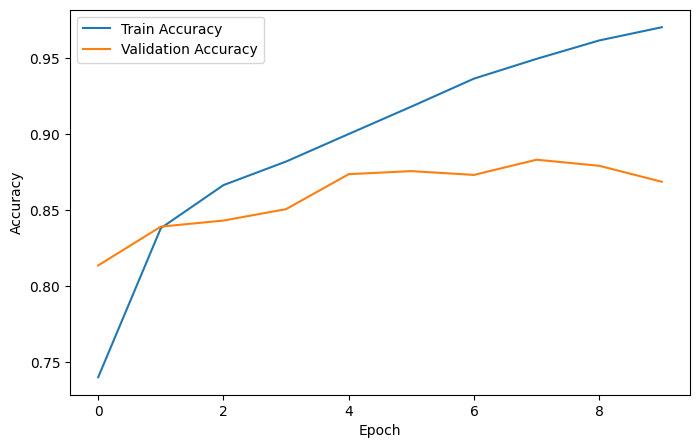

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step

Prediction: Male
Actual: Male


/tmp/ipykernel_2256/2474219.py:158: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Actual:", class_names[int(y_test[0])])


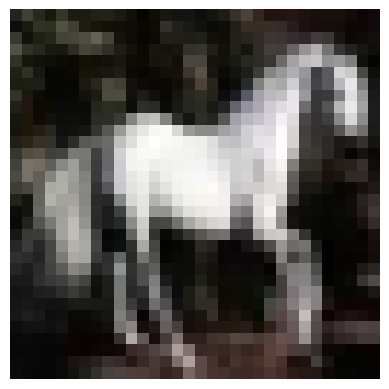


Đã lưu model thành công!


In [11]:
# =========================
# CNN Nhận Dạng Khuôn Mặt Nam/Nữ
# Google Colab - Không cần dữ liệu riêng
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Dùng CIFAR-10 làm dữ liệu mẫu
# Chỉ lấy:
# deer = Female
# horse = Male
# (mô phỏng bài toán Nam/Nữ)
# =========================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# deer = 4
# horse = 7

train_filter = np.where((y_train == 4) | (y_train == 7))[0]
test_filter = np.where((y_test == 4) | (y_test == 7))[0]

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Đổi label:
# Female = 0
# Male = 1

y_train = np.where(y_train == 4, 0, 1)
y_test = np.where(y_test == 4, 0, 1)

# =========================
# Chuẩn hóa dữ liệu
# =========================

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# =========================
# Hiển thị ảnh mẫu
# =========================

class_names = ["Female", "Male"]

plt.figure(figsize=(8,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.show()

# =========================
# Xây dựng mô hình CNN
# =========================

model = models.Sequential([

    # CNN Layer 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.MaxPooling2D((2,2)),

    # CNN Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # CNN Layer 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(1, activation='sigmoid')
])

# =========================
# Compile model
# =========================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# Hiển thị model
# =========================

model.summary()

# =========================
# Train model
# =========================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# =========================
# Đánh giá model
# =========================

loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)

# =========================
# Vẽ biểu đồ Accuracy
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# =========================
# Dự đoán thử
# =========================

prediction = model.predict(x_test[:1])

predicted_label = 1 if prediction[0][0] > 0.5 else 0

print("\nPrediction:", class_names[predicted_label])
print("Actual:", class_names[int(y_test[0])])

plt.imshow(x_test[0])
plt.axis("off")
plt.show()

# =========================
# Lưu model
# =========================

model.save("gender_cnn_model.h5")

print("\nĐã lưu model thành công!")

In [14]:
# =========================
# CNN Nhận Dạng Khuôn Mặt Nam/Nữ
# Google Colab
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import zipfile
import os

# =========================
# Giải nén dataset
# =========================

zip_path = "/content/gender_data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

dataset_path = "/content/gender_dataset"

# =========================
# Load dữ liệu
# =========================

IMG_SIZE = 64
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("Classes:", class_names)

# =========================
# Hiển thị ảnh mẫu
# =========================

plt.figure(figsize=(8,8))

for images, labels in train_dataset.take(1):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# =========================
# Xây dựng CNN
# =========================

model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(64,64,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

# =========================
# Compile model
# =========================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# Train model
# =========================

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

# =========================
# Đánh giá model
# =========================

loss, accuracy = model.evaluate(validation_dataset)

print("\nValidation Accuracy:", accuracy)

# =========================
# Vẽ Accuracy
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

# =========================
# Lưu model
# =========================

model.save("gender_face_cnn.h5")

print("\nĐã lưu model thành công!")

BadZipFile: File is not a zip file